In [51]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

import shap
from lime import lime_tabular

import joblib
from datetime import datetime

In [52]:
df = pd.read_csv('/kaggle/input/fantasy-football/cleaned_merged_seasons.csv')
df.head()


,season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,...,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW
0,2016-17,Aaron Cresswell,DEF,NaN,0,0,0,0,0.0,454,...,2.0,0.0,0,0,0,0,55,False,0,1
1,2016-17,Aaron Lennon,MID,NaN,0,0,6,0,0.3,142,...,1.0,0.0,1,0,0,0,60,True,0,1
2,2016-17,Aaron Ramsey,MID,NaN,0,0,5,0,4.9,16,...,3.0,23.0,2,0,0,0,80,True,0,1
3,2016-17,Abdoulaye Doucouré,MID,NaN,0,0,0,0,0.0,482,...,1.0,0.0,0,0,0,0,50,False,0,1
4,2016-17,Adam Forshaw,MID,NaN,0,0,3,0,1.3,286,...,1.0,0.0,1,0,0,0,45,True,1,1


This loads a CSV file into a pandas DataFrame named df and then displays the first five rows of the dataset.

In [21]:
# Basic information
print("\n1. Dataset Info:")
print(f"   - Total rows: {df.shape[0]:,}")
print(f"   - Total columns: {df.shape[1]}")

print("\n2. Column Names:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i:2d}. {col}")

# Data types
print("\n3. Data Types:")
print(df.dtypes.value_counts())

# Missing values
print("\n4. Missing Values:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing_Count': missing.values,
    'Missing_Percentage': missing_pct.values
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
if len(missing_df) > 0:
    print(missing_df.to_string(index=False))
else:
    print("   No missing values found!")



1. Dataset Info:
   - Total rows: 96,169
   - Total columns: 37

2. Column Names:
    1. season_x
    2. name
    3. position
    4. team_x
    5. assists
    6. bonus
    7. bps
    8. clean_sheets
    9. creativity
   10. element
   11. fixture
   12. goals_conceded
   13. goals_scored
   14. ict_index
   15. influence
   16. kickoff_time
   17. minutes
   18. opponent_team
   19. opp_team_name
   20. own_goals
   21. penalties_missed
   22. penalties_saved
   23. red_cards
   24. round
   25. saves
   26. selected
   27. team_a_score
   28. team_h_score
   29. threat
   30. total_points
   31. transfers_balance
   32. transfers_in
   33. transfers_out
   34. value
   35. was_home
   36. yellow_cards
   37. GW

3. Data Types:
int64      24
object      6
float64     6
bool        1
Name: count, dtype: int64

4. Missing Values:
Column  Missing_Count  Missing_Percentage
team_x          19852           20.642827


before any analysis or modeling, we must understand:
Data structure: What columns exist and their types
Data quality: Missing values, duplicates, data types
Data size: How much data we have to work with

In [53]:
# Columns to remove
columns_to_remove = [
    'ict_index',
    'kickoff_time', 
    'round',
    'selected',
    'transfers_balance',
    'transfers_in',
    'transfers_out'
]

df = df.drop(columns=columns_to_remove)
print(f"\nSuccessfully removed {len(columns_to_remove)} columns")

print(f"REMAINING COLUMNS ({df.shape[1]} total)")
for i, col in enumerate(df.columns, 1):
    print(f"{i:3d}. {col}")


Successfully removed 7 columns
REMAINING COLUMNS (30 total)
  1. season_x
  2. name
  3. position
  4. team_x
  5. assists
  6. bonus
  7. bps
  8. clean_sheets
  9. creativity
 10. element
 11. fixture
 12. goals_conceded
 13. goals_scored
 14. influence
 15. minutes
 16. opponent_team
 17. opp_team_name
 18. own_goals
 19. penalties_missed
 20. penalties_saved
 21. red_cards
 22. saves
 23. team_a_score
 24. team_h_score
 25. threat
 26. total_points
 27. value
 28. was_home
 29. yellow_cards
 30. GW


Remove columns that are either redundant, cause data leakage, or don't contribute meaningful predictive value 

ict_index:
A composite metric combining Influence, Creativity, and Threat into a single score.
Why remove it:
We already have the individual components as separate features

kickoff_time: 
The date and time when the match started.
Why remove it: exact timestamp isn't predictive

round:
We already have GW which contains the same information

selected, transfers_balance, transfers_out:
out of scope of our reseach question 

Impact on Model:
Before removal: Risk of data leakage and redundant features that could:
Cause overfitting (model memorizes patterns that won't exist in real predictions)


In [23]:
# rows with missing team_x
missing_mask = df['team_x'].isna()


# Group by season, GW, and fixture to find team pairs
for (season, gw, fixture), group in df.groupby(['season_x', 'GW', 'fixture']):
    # Get all teams that have team_x filled in this specific fixture 
    known_teams = group[group['team_x'].notna()]['team_x'].unique()
    
    # Get all opponent team names mentioned in this fixture
    opponents = group[group['opp_team_name'].notna()]['opp_team_name'].unique()
    
    # All teams involved in this fixture (combination of known teams and opponents)
    all_teams = set(list(known_teams) + list(opponents))
    
    # If we have exactly 2 teams, we can fill missing values
    if len(all_teams) == 2:
        team1, team2 = list(all_teams)
        
        # For each row with missing team_x in this fixture
        missing_in_group = group[group['team_x'].isna()]
        
        for idx in missing_in_group.index:
            opponent_name = df.at[idx, 'opp_team_name']
            
            # If opponent is team1, then player's team is team2 (and vice versa)
            if pd.notna(opponent_name):
                if opponent_name == team1:
                    df.at[idx, 'team_x'] = team2
                   
                elif opponent_name == team2:
                    df.at[idx, 'team_x'] = team1
                    

Some rows have missing team_x values.

Team is a critical feature: A player's team affects their performance.
Missing team data: prevents us from using team-related features
Can't drop all missing rows: Would lose too much data

Solution Strategy:
get missing team from opponent and fixture data:
each fixture has exactly 2 teams playing against each other.
If we know the opponent team, we can get the player's team
Group by (season, gameweek, fixture) to find team pairs

If fixture has teams A and B:
If player's opponent is A → player's team is B
If player's opponent is B → player's team is A

Validation: Show examples of filled values to verify correctness


In [24]:
# Count null values
null_count = df.isnull().sum().sum()
print(f"\nTotal null/NaN cells: {null_count}")



Total null/NaN cells: 0


to make sure I filled all team_x values and there is no missing value

In [25]:
df.head()

,season_x,name,position,team_x,assists,bonus,bps,clean_sheets,creativity,element,...,red_cards,saves,team_a_score,team_h_score,threat,total_points,value,was_home,yellow_cards,GW
0,2016-17,Aaron Cresswell,DEF,West Ham,0,0,0,0,0.0,454,...,0,0,1.0,2.0,0.0,0,55,False,0,1
1,2016-17,Aaron Lennon,MID,Everton,0,0,6,0,0.3,142,...,0,0,1.0,1.0,0.0,1,60,True,0,1
2,2016-17,Aaron Ramsey,MID,Arsenal,0,0,5,0,4.9,16,...,0,0,4.0,3.0,23.0,2,80,True,0,1
3,2016-17,Abdoulaye Doucouré,MID,Watford,0,0,0,0,0.0,482,...,0,0,1.0,1.0,0.0,0,50,False,0,1
4,2016-17,Adam Forshaw,MID,Middlesbrough,0,0,3,0,1.3,286,...,0,0,1.0,1.0,0.0,1,45,True,1,1


to make sure the team is correct

In [26]:
# Exact duplicates
print("EXACT DUPLICATES (all columns):")
exact_dup_mask = df.duplicated(keep=False)
exact_dup_count = exact_dup_mask.sum()

if exact_dup_count > 0:
    print("\n   Example of exact duplicates:")
    print(df[exact_dup_mask].head(10)[['name', 'season_x', 'GW', 'team_x', 'fixture', 'minutes', 'total_points']])

# Partial duplicates
partial_dup_mask = df.duplicated(subset=['name', 'season_x', 'GW'], keep=False)
partial_dup_count = partial_dup_mask.sum()

print(f"Total rows: {len(df):,}")
print(f"Exact duplicates: {exact_dup_count:,}")
print(f"Partial duplicates: {partial_dup_count:,}")

df = df.drop_duplicates()  # removes exact duplicates
df = df.drop_duplicates(subset=['name', 'season_x', 'GW'], keep='first')  # removes partial duplicates

print(f"\nAfter removing duplicates: {df.shape}")


EXACT DUPLICATES (all columns):
Total rows: 96,169
Exact duplicates: 0
Partial duplicates: 11,774

After removing duplicates: (90255, 30)


Checking for Duplicate Rows

Why Check for Duplicates?
Duplicates can severely bias machine learning models:
Inflated performance: Same data point counted multiple times
Data leakage: Same instance in both train and test sets
Overfitting: Model memorizes duplicates instead of learning patterns

Two Types of Duplicates:
Exact Duplicates (all columns identical)
Partial Duplicates (same player, season, gameweek)

Each player should have one row per gameweek
Multiple rows for same player/gameweek indicates data quality issues
Must resolve before modeling to ensure clean training data


In [58]:
#position of player
#Ensure positions are: GK, DEF, MID, FWD

# Check current positions
print("\nCurrent position values:")
position_counts = df['position'].value_counts()
print(position_counts)

# Create mapping
position_mapping = {
    'GK': 'GK',
    'GKP': 'GK',
    'DEF': 'DEF',
    'MID': 'MID',
    'FWD': 'FWD'
}

# Apply mapping
df['position'] = df['position'].map(position_mapping)

# Check for any unmapped values
unmapped = df[df['position'].isna()]
if len(unmapped) > 0:
    print(f"{len(unmapped)} rows with unmapped positions!")
    print("\nUnmapped position values:")
    print(unmapped['position'].value_counts())
else:
    print("All positions mapped successfully")

print("AFTER UPDATE - Position counts:")
position_counts_after = df['position'].value_counts()
print(position_counts_after)

print(f"Unique positions: {df['position'].unique()}")
print(f"Total rows: {len(df):,}")


Current position values:
position
MID    39163
DEF    33683
FWD    12669
GK     10654
Name: count, dtype: int64
All positions mapped successfully
AFTER UPDATE - Position counts:
position
MID    39163
DEF    33683
FWD    12669
GK     10654
Name: count, dtype: int64
Position standardization complete!
Unique positions: ['DEF' 'MID' 'GK' 'FWD']
Total rows: 96,169


Position column has inconsistent values (GK, GKP for goalkeepers).

Inconsistency reduces model's ability to learn position-based patterns
Standard categories make analysis clearer

Standardization Mapping:
GK, GKP → GK (Goalkeeper)
DEF → DEF (Defender)
MID → MID (Midfielder)
FWD → FWD (Forward)

Before: Show position value counts (GK, GKP, DEF, MID, FWD)
After: Show standardized counts (GK, DEF, MID, FWD)


In [28]:
#data type
"""
Standardize Data Types - Remove rows with incorrect types
"""
import pandas as pd
import numpy as np

print("=" * 80)
print("CHECKING AND STANDARDIZING DATA TYPES")
print("=" * 80)

initial_rows = len(df)
print(f"\nInitial row count: {initial_rows:,}")

# Show current data types
print("\n" + "=" * 80)
print("CURRENT DATA TYPES:")
print("=" * 80)
print(df.dtypes)

# Define expected data types for each column
expected_types = {
    'season_x': 'object',
    'name': 'object',
    'position': 'object',
    'team_x': 'object',
    'assists': 'numeric',
    'bonus': 'numeric',
    'bps': 'numeric',
    'clean_sheets': 'numeric',
    'creativity': 'numeric',
    'element': 'numeric',
    'fixture': 'numeric',
    'goals_conceded': 'numeric',
    'goals_scored': 'numeric',
    'ict_index': 'numeric',
    'influence': 'numeric',
    'kickoff_time': 'object',
    'minutes': 'numeric',
    'opponent_team': 'numeric',
    'opp_team_name': 'object',
    'own_goals': 'numeric',
    'penalties_missed': 'numeric',
    'penalties_saved': 'numeric',
    'red_cards': 'numeric',
    'round': 'numeric',
    'saves': 'numeric',
    'selected': 'numeric',
    'team_a_score': 'numeric',
    'team_h_score': 'numeric',
    'threat': 'numeric',
    'total_points': 'numeric',
    'transfers_balance': 'numeric',
    'transfers_in': 'numeric',
    'transfers_out': 'numeric',
    'value': 'numeric',
    'was_home': 'bool',
    'yellow_cards': 'numeric',
    'GW': 'numeric',
    'form': 'numeric'
}

# Track rows to remove
rows_to_remove = pd.Series([False] * len(df))
issues_found = []

print("\n" + "=" * 80)
print("CHECKING EACH COLUMN FOR TYPE MISMATCHES:")
print("=" * 80)

for col in df.columns:
    if col not in expected_types:
        print(f"\n⚠ Column '{col}' not in expected types - skipping")
        continue
    
    expected = expected_types[col]
    
    if expected == 'numeric':
        # Check for non-numeric values
        numeric_check = pd.to_numeric(df[col], errors='coerce')
        invalid_mask = numeric_check.isna() & df[col].notna()
        invalid_count = invalid_mask.sum()
        
        if invalid_count > 0:
            print(f"\n✗ {col}: {invalid_count} rows with non-numeric values")
            # Show examples
            examples = df[invalid_mask][col].head(5).tolist()
            print(f"   Examples: {examples}")
            rows_to_remove |= invalid_mask
            issues_found.append((col, invalid_count, 'non-numeric'))
        else:
            print(f"✓ {col}: All values are numeric")
            
    elif expected == 'object':
        # Check that values are strings or null
        non_string_mask = ~df[col].apply(lambda x: isinstance(x, (str, type(None), np.str_)))
        invalid_count = non_string_mask.sum()
        
        if invalid_count > 0:
            print(f"\n✗ {col}: {invalid_count} rows with non-string values")
            # Show examples
            examples = df[non_string_mask][col].head(5).tolist()
            print(f"   Examples: {examples}")
            rows_to_remove |= non_string_mask
            issues_found.append((col, invalid_count, 'non-string'))
        else:
            print(f"✓ {col}: All values are strings or null")
            
    elif expected == 'bool':
        # Check that values are boolean
        non_bool_mask = ~df[col].apply(lambda x: isinstance(x, (bool, np.bool_)))
        invalid_count = non_bool_mask.sum()
        
        if invalid_count > 0:
            print(f"\n✗ {col}: {invalid_count} rows with non-boolean values")
            # Show examples
            examples = df[non_bool_mask][col].head(5).tolist()
            print(f"   Examples: {examples}")
            rows_to_remove |= non_bool_mask
            issues_found.append((col, invalid_count, 'non-boolean'))
        else:
            print(f"✓ {col}: All values are boolean")

# Summary of issues
print("\n" + "=" * 80)
print("ISSUES SUMMARY:")
print("=" * 80)

if len(issues_found) > 0:
    print(f"\nFound issues in {len(issues_found)} columns:")
    for col, count, issue_type in issues_found:
        print(f"  - {col}: {count} rows with {issue_type} values")
    
    total_rows_to_remove = rows_to_remove.sum()
    print(f"\nTotal unique rows to remove: {total_rows_to_remove:,}")
    
    if total_rows_to_remove > 0:
        # Show sample of rows to be removed
        print("\n" + "=" * 80)
        print("SAMPLE ROWS TO BE REMOVED (first 10):")
        print("=" * 80)
        sample_remove = df[rows_to_remove][['name', 'season_x', 'GW', 'team_x', 'total_points']].head(10)
        print(sample_remove.to_string(index=False))
        
        # Remove rows
        print("\n" + "=" * 80)
        print("REMOVING ROWS WITH INCORRECT DATA TYPES...")
        print("=" * 80)
        df = df[~rows_to_remove].copy()
        df = df.reset_index(drop=True)
        
        final_rows = len(df)
        removed = initial_rows - final_rows
        
        print(f"Rows removed: {removed:,}")
        print(f"Final row count: {final_rows:,}")
    else:
        print("\nNo rows to remove!")
else:
    print("✓ No data type issues found!")

print("\n" + "=" * 80)
print("FINAL DATA TYPES:")
print("=" * 80)
print(df.dtypes)

print("\n✓ DONE")

CHECKING AND STANDARDIZING DATA TYPES

Initial row count: 90,255

CURRENT DATA TYPES:
season_x             object
name                 object
position             object
team_x               object
assists               int64
bonus                 int64
bps                   int64
clean_sheets          int64
creativity          float64
element               int64
fixture               int64
goals_conceded        int64
goals_scored          int64
influence           float64
minutes               int64
opponent_team         int64
opp_team_name        object
own_goals             int64
penalties_missed      int64
penalties_saved       int64
red_cards             int64
saves                 int64
team_a_score        float64
team_h_score        float64
threat              float64
total_points          int64
value                 int64
was_home               bool
yellow_cards          int64
GW                    int64
dtype: object

CHECKING EACH COLUMN FOR TYPE MISMATCHES:
✓ season_x: All v

## Step 5: Data Type Validation

### Why Validate Data Types?
**Incorrect data types cause model failures:**
- **Numeric columns with strings** - Can't calculate statistics or train models
- **Boolean columns with numbers** - Logical operations fail
- **Mixed types** - Unpredictable behavior

### Validation Strategy:
For each column, check:
1. **Numeric columns** - Should only contain numbers (or NaN)
2. **String columns** - Should only contain text
3. **Boolean columns** - Should only contain True/False

### What We Do With Errors:
**Remove rows with incorrect types** because:
- Can't reliably convert incorrect values
- Incorrect types indicate data quality issues
- Better to lose a few rows than corrupt the entire dataset

### Expected Outcome:
- Most columns should be clean
- A few rows might be removed due to data entry errors
- Final dataset has consistent, model-ready data types

---



   Analyzing selected player: 'Mohamed Salah'
Mohamed Salah        2017-18      1            11  0.000000
Mohamed Salah        2017-18      2             1  1.100000
Mohamed Salah        2017-18      3            11  0.600000
Mohamed Salah        2017-18      4             1  0.766667
Mohamed Salah        2017-18      5            10  0.600000
Mohamed Salah        2017-18      6             7  0.575000
Mohamed Salah        2017-18      7             2  0.725000
Mohamed Salah        2017-18      8             3  0.500000
Mohamed Salah        2017-18      9             7  0.550000
Mohamed Salah        2017-18     10             4  0.475000
Mohamed Salah        2017-18     11            15  0.400000
Mohamed Salah        2017-18     12            16  0.725000
Mohamed Salah        2017-18     13             7  1.050000
Mohamed Salah        2017-18     14            13  1.050000
Mohamed Salah        2017-18     15             5  1.275000
Mohamed Salah        2017-18     16            11  1.

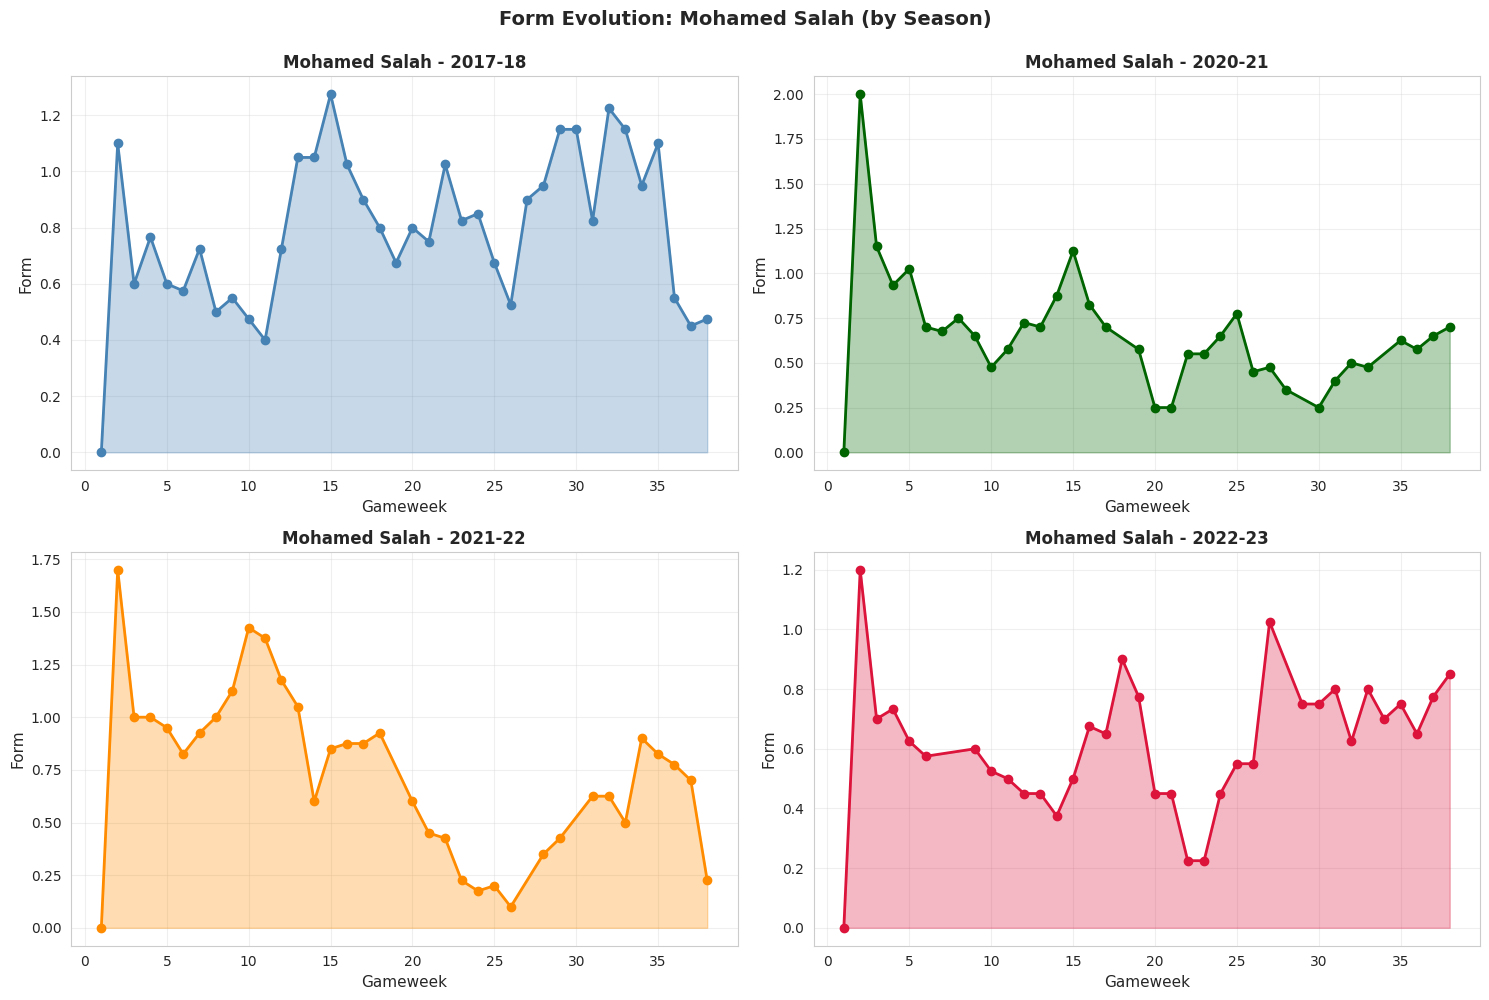


2. Column Names:
    1. season_x
    2. name
    3. position
    4. team_x
    5. assists
    6. bonus
    7. bps
    8. clean_sheets
    9. creativity
   10. element
   11. fixture
   12. goals_conceded
   13. goals_scored
   14. influence
   15. minutes
   16. opponent_team
   17. opp_team_name
   18. own_goals
   19. penalties_missed
   20. penalties_saved
   21. red_cards
   22. saves
   23. team_a_score
   24. team_h_score
   25. threat
   26. total_points
   27. value
   28. was_home
   29. yellow_cards
   30. GW
   31. form


In [29]:
"""
Cell 5: Feature Engineering - Calculate Form
Run this after Cell 4 (Data Cleaning)
Form = Average of previous 4 gameweeks' total_points / 10
"""
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PLAYER_TO_ANALYZE = "Mohamed Salah"  # Change this to any player name

name_cols = [col for col in df.columns if 'name' in col.lower()]
gw_cols = [col for col in df.columns if any(x in col.lower() for x in ['round', 'gw', 'gameweek'])]
points_cols = [col for col in df.columns if 'total_points' in col.lower() or col.lower() == 'points']

if not name_cols:
    raise ValueError("Could not find player name column")
if not gw_cols:
    raise ValueError("Could not find gameweek/round column")
if not points_cols:
    raise ValueError("Could not find total_points column")

name_col = name_cols[0]
gw_col = gw_cols[0]
points_col = points_cols[0]

# Step 2: Sort data by player, season, and gameweek
df = df.sort_values([name_col, 'season_x', gw_col]).reset_index(drop=True)

# Calculate rolling average of previous 4 gameweeks (grouped by player AND season)
df['form'] = df.groupby([name_col, 'season_x'])[points_col].transform(
    lambda x: x.rolling(window=4, min_periods=1).mean().shift(1)
) / 10

# For the first gameweek of each player, form should be NaN or 0
# We'll set it to 0 for consistency
df['form'] = df['form'].fillna(0)

sample_player = PLAYER_TO_ANALYZE
if sample_player not in df[name_col].values:
    print(f"\n   WARNING: Player '{sample_player}' not found in dataset!")
    sample_player = df.groupby(name_col).size().sort_values(ascending=False).index[0]
    print(f"   Using most common player instead: '{sample_player}'")
else:
    print(f"\n   Analyzing selected player: '{sample_player}'")

verify_data = df[df[name_col] == sample_player].copy()
for idx, row in verify_data.iterrows():
    player_name = row[name_col]
    season = row['season_x']
    gw = int(row[gw_col])
    points = row[points_col]
    form = row['form']
    
    # Format: "Player Name  Season  GW  Points  Form"
    print(f"{player_name:<20} {season:<10} {gw:>3}  {points:>12.0f}  {form:.6f}")

# Check for any issues
zero_form_count = (df['form'] == 0).sum()
print(f"\n   Rows with form = 0: {zero_form_count:,} (expected for early gameweeks)")

# Set style
sns.set_style("whitegrid")

# Get player data
player_data = df[df[name_col] == sample_player]

# Get unique seasons
seasons = sorted(player_data['season_x'].unique())
num_seasons = len(seasons)

# Create subplots - 2x2 grid for up to 4 seasons, or adjust as needed
if num_seasons <= 4:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten()
else:
    # If more than 4 seasons, create more subplots
    rows = (num_seasons + 1) // 2
    fig, axes = plt.subplots(rows, 2, figsize=(15, 5 * rows))
    axes = axes.flatten()

# Define colors for each season
colors = ['steelblue', 'darkgreen', 'darkorange', 'crimson', 'purple', 'brown', 'pink', 'gray']

# Plot each season
for i, season in enumerate(seasons):
    season_data = player_data[player_data['season_x'] == season]
    
    axes[i].plot(season_data[gw_col], season_data['form'], marker='o', 
                 linewidth=2, markersize=6, color=colors[i % len(colors)])
    axes[i].fill_between(season_data[gw_col], season_data['form'], 
                         alpha=0.3, color=colors[i % len(colors)])
    axes[i].set_xlabel('Gameweek', fontsize=11)
    axes[i].set_ylabel('Form', fontsize=11)
    axes[i].set_title(f'{sample_player} - {season}', fontsize=12, fontweight='bold')
    axes[i].grid(True, alpha=0.3)

# Hide any unused subplots
for i in range(len(seasons), len(axes)):
    axes[i].axis('off')

plt.suptitle(f'Form Evolution: {sample_player} (by Season)', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Print new columns
print("\n2. Column Names:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i:2d}. {col}")

## Step 6: Feature Engineering - Calculating "Form"

### What is Form?
**Form = Average of previous 4 gameweeks' total_points ÷ 10**

### Why Create This Feature?
**Recent performance predicts future performance:**
- A player "in form" (scoring well recently) is likely to continue
- A player "out of form" (scoring poorly) is likely to struggle
- Form captures momentum and current fitness/confidence

### Why Previous 4 Gameweeks?
**Balance between recency and stability:**
- **Too few games (1-2)** - Too volatile, one bad game skews the metric
- **Too many games (8+)** - Too slow to react to form changes
- **4 games** - Industry standard in fantasy football, captures recent trend

### Why Divide by 10?
**Normalization for model training:**
- Raw points range from 0-20+ per gameweek
- Form ranges from 0-2 (more manageable scale)
- Helps neural networks train more efficiently

### Implementation Details:
\`\`\`python
df['form'] = df.groupby(['name', 'season_x'])['total_points']
    .transform(lambda x: x.rolling(window=4, min_periods=1).mean().shift(1)) / 10
\`\`\`

**Key aspects:**
- `groupby(['name', 'season_x'])` - Calculate per player, per season
- `rolling(window=4)` - Use previous 4 gameweeks
- `shift(1)` - Shift by 1 to avoid data leakage (don't include current gameweek)
- `min_periods=1` - Allow calculation even with fewer than 4 games (early season)

### Evidence of Correctness:
**Visualization:** Plot form evolution for a sample player across a season
- Should show smooth trends (not erratic jumps)
- Should lag behind actual points (because it's based on previous games)
- Should be 0 or low for first few gameweeks (not enough history)

**Manual Verification:** Show calculation for specific player/gameweeks
- Verify form = (sum of previous 4 gameweeks' points / 4) / 10

### Why This Feature is Powerful:
- **Captures momentum** - Hot streaks and cold streaks
- **Time-aware** - Recent games matter more than old games
- **Proven in fantasy football** - Widely used by successful managers

---


In [30]:
"""
Print Sample Rows from Dataset
First 50, Random 50 from middle, Last 50
"""


print("=" * 80)
print("DATASET SAMPLE ROWS")
print("=" * 80)

total_rows = len(df)
print(f"\nTotal rows in dataset: {total_rows:,}\n")

# Select columns to display (adjust as needed)
display_cols = ['name', 'season_x', 'GW', 'position', 'team_x', 'opp_team_name', 
                'minutes', 'total_points', 'form']

# ================================================================
# FIRST 50 ROWS
# ================================================================
print("=" * 80)
print("FIRST 50 ROWS")
print("=" * 80)
first_50 = df.head(50)
print(first_50[display_cols].to_string(index=True))

# ================================================================
# RANDOM 50 FROM MIDDLE
# ================================================================
print("\n" + "=" * 80)
print("RANDOM 50 ROWS FROM MIDDLE")
print("=" * 80)

# Define middle range (middle 50% of the dataset)
start_middle = int(total_rows * 0.25)
end_middle = int(total_rows * 0.75)

# Get random indices from middle range
middle_indices = np.random.choice(range(start_middle, end_middle), 
                                   size=min(50, end_middle - start_middle), 
                                   replace=False)
middle_indices = sorted(middle_indices)

middle_50 = df.iloc[middle_indices]
print(middle_50[display_cols].to_string(index=True))

# ================================================================
# LAST 50 ROWS
# ================================================================
print("\n" + "=" * 80)
print("LAST 50 ROWS")
print("=" * 80)
last_50 = df.tail(50)
print(last_50[display_cols].to_string(index=True))

# ================================================================
# SUMMARY STATISTICS
# ================================================================
print("\n" + "=" * 80)
print("SUMMARY STATISTICS FOR SAMPLES")
print("=" * 80)

for sample_name, sample_df in [("First 50", first_50), 
                                ("Middle 50", middle_50), 
                                ("Last 50", last_50)]:
    print(f"\n{sample_name}:")
    print(f"  Unique players: {sample_df['name'].nunique()}")
    print(f"  Unique seasons: {sample_df['season_x'].nunique()}")
    print(f"  Unique teams: {sample_df['team_x'].nunique()}")
    print(f"  Gameweek range: {sample_df['GW'].min()} - {sample_df['GW'].max()}")
    print(f"  Positions: {sample_df['position'].value_counts().to_dict()}")
    print(f"  Avg total_points: {sample_df['total_points'].mean():.2f}")
    print(f"  Avg form: {sample_df['form'].mean():.4f}")

print("\n✓ DONE")

DATASET SAMPLE ROWS

Total rows in dataset: 90,255

FIRST 50 ROWS
              name season_x  GW position    team_x   opp_team_name  minutes  total_points      form
0   Aaron Connolly  2020-21   1      FWD  Brighton         Chelsea       45             1  0.000000
1   Aaron Connolly  2020-21   2      FWD  Brighton       Newcastle       89             8  0.100000
2   Aaron Connolly  2020-21   3      FWD  Brighton         Man Utd       73             2  0.450000
3   Aaron Connolly  2020-21   4      FWD  Brighton         Everton       65             2  0.366667
4   Aaron Connolly  2020-21   5      FWD  Brighton  Crystal Palace       12             4  0.325000
5   Aaron Connolly  2020-21   6      FWD  Brighton       West Brom        0             0  0.400000
6   Aaron Connolly  2020-21   7      FWD  Brighton           Spurs        0             0  0.200000
7   Aaron Connolly  2020-21   8      FWD  Brighton         Burnley        4             1  0.150000
8   Aaron Connolly  2020-21   9   

In [31]:
"""
Verify Form Calculation - Random Samples
"""
import pandas as pd
import numpy as np

print("=" * 80)
print("VERIFYING FORM CALCULATION - RANDOM SAMPLES")
print("=" * 80)

# Take random samples from different parts of the dataframe
sample_size = 5
num_samples = 4

print(f"\nShowing {num_samples} random samples of {sample_size} consecutive rows each\n")

for sample_num in range(num_samples):
    # Get a random starting point
    random_start = np.random.randint(0, len(df) - sample_size * 10)
    sample_df = df.iloc[random_start:random_start + sample_size * 10].copy()
    
    # Pick a random player from this sample
    random_player = sample_df['name'].iloc[np.random.randint(0, len(sample_df))]
    
    # Get consecutive rows for this player
    player_df = df[df['name'] == random_player].copy()
    
    if len(player_df) >= sample_size:
        # Get a random starting gameweek
        random_season = player_df['season_x'].iloc[np.random.randint(0, len(player_df))]
        season_df = player_df[player_df['season_x'] == random_season]
        
        if len(season_df) >= sample_size:
            start_idx = np.random.randint(0, len(season_df) - sample_size + 1)
            sample = season_df.iloc[start_idx:start_idx + sample_size]
            
            print("=" * 80)
            print(f"SAMPLE {sample_num + 1}: {random_player} - {random_season}")
            print("=" * 80)
            
            # Manual calculation to verify
            for i, (idx, row) in enumerate(sample.iterrows()):
                gw = row['GW']
                points = row['total_points']
                form_in_df = row['form']
                
                # Calculate what form SHOULD be (average of previous 4 GWs / 10)
                # Get previous rows for this player in this season
                prev_rows = season_df[season_df['GW'] < gw].tail(4)
                
                if len(prev_rows) > 0:
                    expected_form = prev_rows['total_points'].mean() / 10
                else:
                    expected_form = 0.0
                
                # Check if it matches
                match = "✓" if abs(form_in_df - expected_form) < 0.001 else "✗"
                
                print(f"GW {gw:>2} | Points: {points:>2} | Form: {form_in_df:.4f} | Expected: {expected_form:.4f} | {match}")
                
                # Show previous GWs used in calculation
                if len(prev_rows) > 0:
                    prev_gws = prev_rows['GW'].tolist()
                    prev_points = prev_rows['total_points'].tolist()
                    print(f"       Previous GWs: {prev_gws} -> Points: {prev_points}")
            
            print()

print("=" * 80)
print("SUMMARY")
print("=" * 80)
print("✓ = Form matches expected calculation")
print("✗ = Form does NOT match (possible error!)")
print("\nForm should be: (average of previous 4 gameweeks' total_points) / 10")
print("First few gameweeks of each season should have form = 0 or based on fewer games")

VERIFYING FORM CALCULATION - RANDOM SAMPLES

Showing 4 random samples of 5 consecutive rows each

SAMPLE 1: Emerson Palmieri dos Santos - 2021-22
GW  2 | Points:  0 | Form: 0.1000 | Expected: 0.1000 | ✓
       Previous GWs: [1] -> Points: [1]
GW  3 | Points:  0 | Form: 0.0500 | Expected: 0.0500 | ✓
       Previous GWs: [1, 2] -> Points: [1, 0]
GW  4 | Points:  0 | Form: 0.0333 | Expected: 0.0333 | ✓
       Previous GWs: [1, 2, 3] -> Points: [1, 0, 0]
GW  5 | Points:  0 | Form: 0.0250 | Expected: 0.0250 | ✓
       Previous GWs: [1, 2, 3, 4] -> Points: [1, 0, 0, 0]
GW  6 | Points:  0 | Form: 0.0000 | Expected: 0.0000 | ✓
       Previous GWs: [2, 3, 4, 5] -> Points: [0, 0, 0, 0]

SAMPLE 2: Dion Sanderson - 2021-22
GW 31 | Points:  0 | Form: 0.0000 | Expected: 0.0000 | ✓
       Previous GWs: [27, 28, 29, 30] -> Points: [0, 0, 0, 0]
GW 32 | Points:  0 | Form: 0.0000 | Expected: 0.0000 | ✓
       Previous GWs: [28, 29, 30, 31] -> Points: [0, 0, 0, 0]
GW 34 | Points:  0 | Form: 0.0000 | Expec


Using columns: total_points (points), position (position)

POSITION PERFORMANCE ANALYSIS
          Total_Points_Sum  Average_Points  Player_Count
position                                                
FWD                  18874            1.58         11914
MID                  53822            1.46         36768
DEF                  40901            1.29         31593
GK                   11649            1.17          9980

Best Position: FWD with 1.58 average points


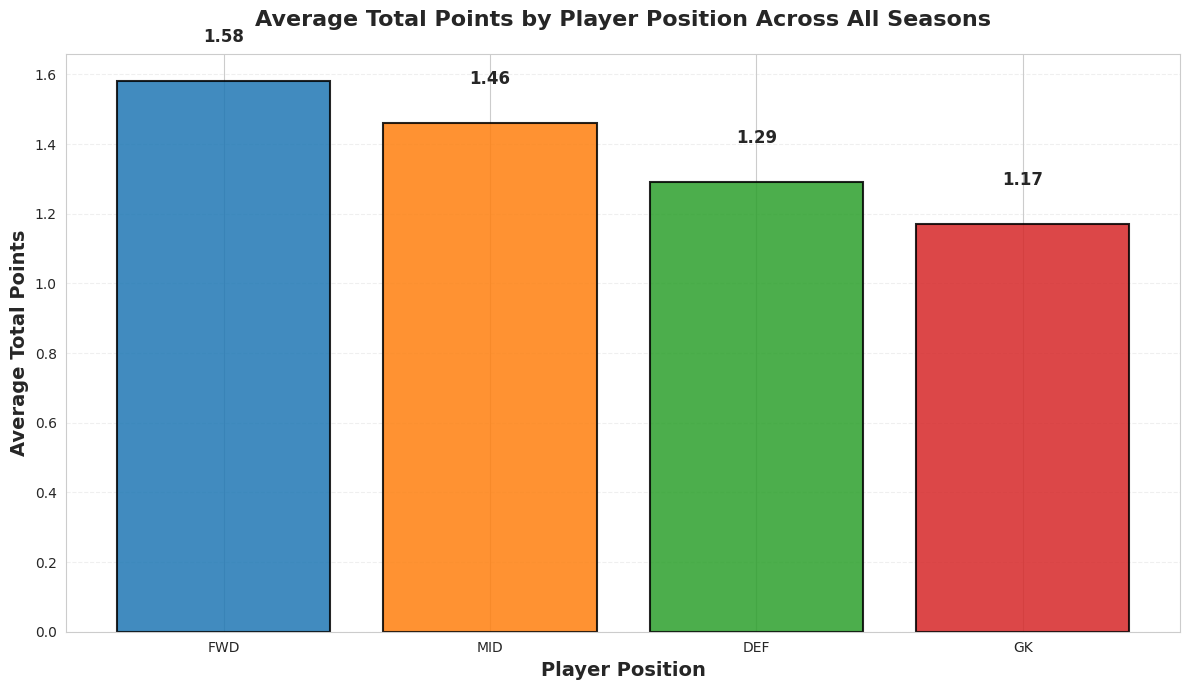


REASONING
   - FWDs typically have more opportunities to score points through:
     • Goals and assists (high point values)
     • Bonus points for match performance
     • Consistent playing time
   - Defenders and Goalkeepers rely more on clean sheets, which are less frequent


In [32]:
"""
Cell 6: Position Analysis
Analyzes which player positions score the most points on average
"""
# Detect points column
points_col = None
for col in ['total_points', 'points', 'total_pts', 'pts', 'points_per_game']:
    if col in df.columns:
        points_col = col
        break

# Detect position column
position_col = None
for col in ['position', 'pos', 'player_position', 'Position', 'element_type', 
            'position_id', 'singular_name', 'singular_name_short', 'type']:
    if col in df.columns:
        position_col = col
        break

if not points_col or not position_col:
    raise KeyError(f"Required columns not found. Available columns: {df.columns.tolist()}")

print(f"\nUsing columns: {points_col} (points), {position_col} (position)")

# If position is numeric (1=GK, 2=DEF, 3=MID, 4=FWD), map to names
if df[position_col].dtype in ['int64', 'int32', 'float64']:
    position_mapping = {1: 'Goalkeeper', 2: 'Defender', 3: 'Midfielder', 4: 'Forward'}
    df['position_name'] = df[position_col].map(position_mapping)
    position_col = 'position_name'
    print("Mapped numeric positions to names")

# Calculate average total points by position across all seasons
position_performance = df.groupby(position_col).agg({
    points_col: ['sum', 'mean', 'count']
}).round(2)

position_performance.columns = ['Total_Points_Sum', 'Average_Points', 'Player_Count']
position_performance = position_performance.sort_values('Average_Points', ascending=False)

print("\n" + "="*60)
print("POSITION PERFORMANCE ANALYSIS")
print("="*60)
print(position_performance)
print("="*60)

best_position = position_performance.index[0]
best_avg_points = position_performance['Average_Points'].iloc[0]
print(f"\nBest Position: {best_position} with {best_avg_points:.2f} average points")

# Visualization
fig, ax = plt.subplots(figsize=(12, 7))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
bars = ax.bar(position_performance.index, position_performance['Average_Points'], 
              color=colors[:len(position_performance)], edgecolor='black', alpha=0.85, linewidth=1.5)

ax.set_xlabel('Player Position', fontsize=14, fontweight='bold')
ax.set_ylabel('Average Total Points', fontsize=14, fontweight='bold')
ax.set_title('Average Total Points by Player Position Across All Seasons', 
             fontsize=16, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on top of bars
for i, (bar, v) in enumerate(zip(bars, position_performance['Average_Points'])):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
            f'{v:.2f}',
            ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("REASONING")
print("="*60)
print(f"   - {best_position}s typically have more opportunities to score points through:")
print("     • Goals and assists (high point values)")
print("     • Bonus points for match performance")
print("     • Consistent playing time")
print("   - Defenders and Goalkeepers rely more on clean sheets, which are less frequent")
print("="*60)


## Step 7: Exploratory Analysis - Which Positions Score Most?

### Research Question:
**Do certain positions consistently score more fantasy points than others?**

### Why This Matters:
**Position-based strategy in fantasy football:**
- If forwards score more on average, prioritize forwards in team selection
- If defenders score less, budget allocation should reflect this
- Understanding position value informs transfer decisions

### Analysis Approach:
1. **Group by position** - Calculate total and average points per position
2. **Visualize** - Bar chart showing average points by position
3. **Interpret** - Explain why certain positions score more

### Expected Findings:
**Hypothesis:** Forwards and Midfielders score more than Defenders and Goalkeepers

**Why?**
- **Forwards** - Primary goal scorers (6 points per goal)
- **Midfielders** - Goals (5 points) + Assists (3 points) + Bonus points
- **Defenders** - Rely on clean sheets (4 points) which are less frequent
- **Goalkeepers** - Limited scoring opportunities (saves, clean sheets)

### Evidence:
**Bar Chart:** Average total points by position
- X-axis: Position (GK, DEF, MID, FWD)
- Y-axis: Average total points
- Expected order: FWD > MID > DEF > GK

**Statistics Table:**
- Total points sum per position
- Average points per position
- Number of players per position

### Interpretation:
If forwards score highest:
- **Confirms** attacking players are more valuable
- **Informs** team selection (invest in premium forwards)
- **Validates** fantasy football conventional wisdom

### Why This Analysis Helps Our Model:
- **Position is a key feature** - Model will learn position-based scoring patterns
- **Feature importance** - Position should rank high in SHAP analysis later
- **Validates data quality** - If results are nonsensical, indicates data issues

---


Found 24922 records for 2022-23 season

1. Top 5 Players by Total Points (2022-23):
   1. Harry Kane: 258 points
   2. Brandon Williams: 247 points
   3. Axel Tuanzebe: 219 points
   4. Granit Xhaka: 202 points
   5. Alfie Mawson: 186 points

2. Top 5 Players by Average Form (2022-23):
   1. Brandon Williams: 0.76 form
   2. Harry Kane: 0.64 form
   3. Axel Tuanzebe: 0.62 form
   4. Granit Xhaka: 0.55 form
   5. DeAndre Yedlin: 0.54 form

3. Players in Both Top 5 Lists: 4 out of 5
   - Players: Axel Tuanzebe, Harry Kane, Brandon Williams, Granit Xhaka


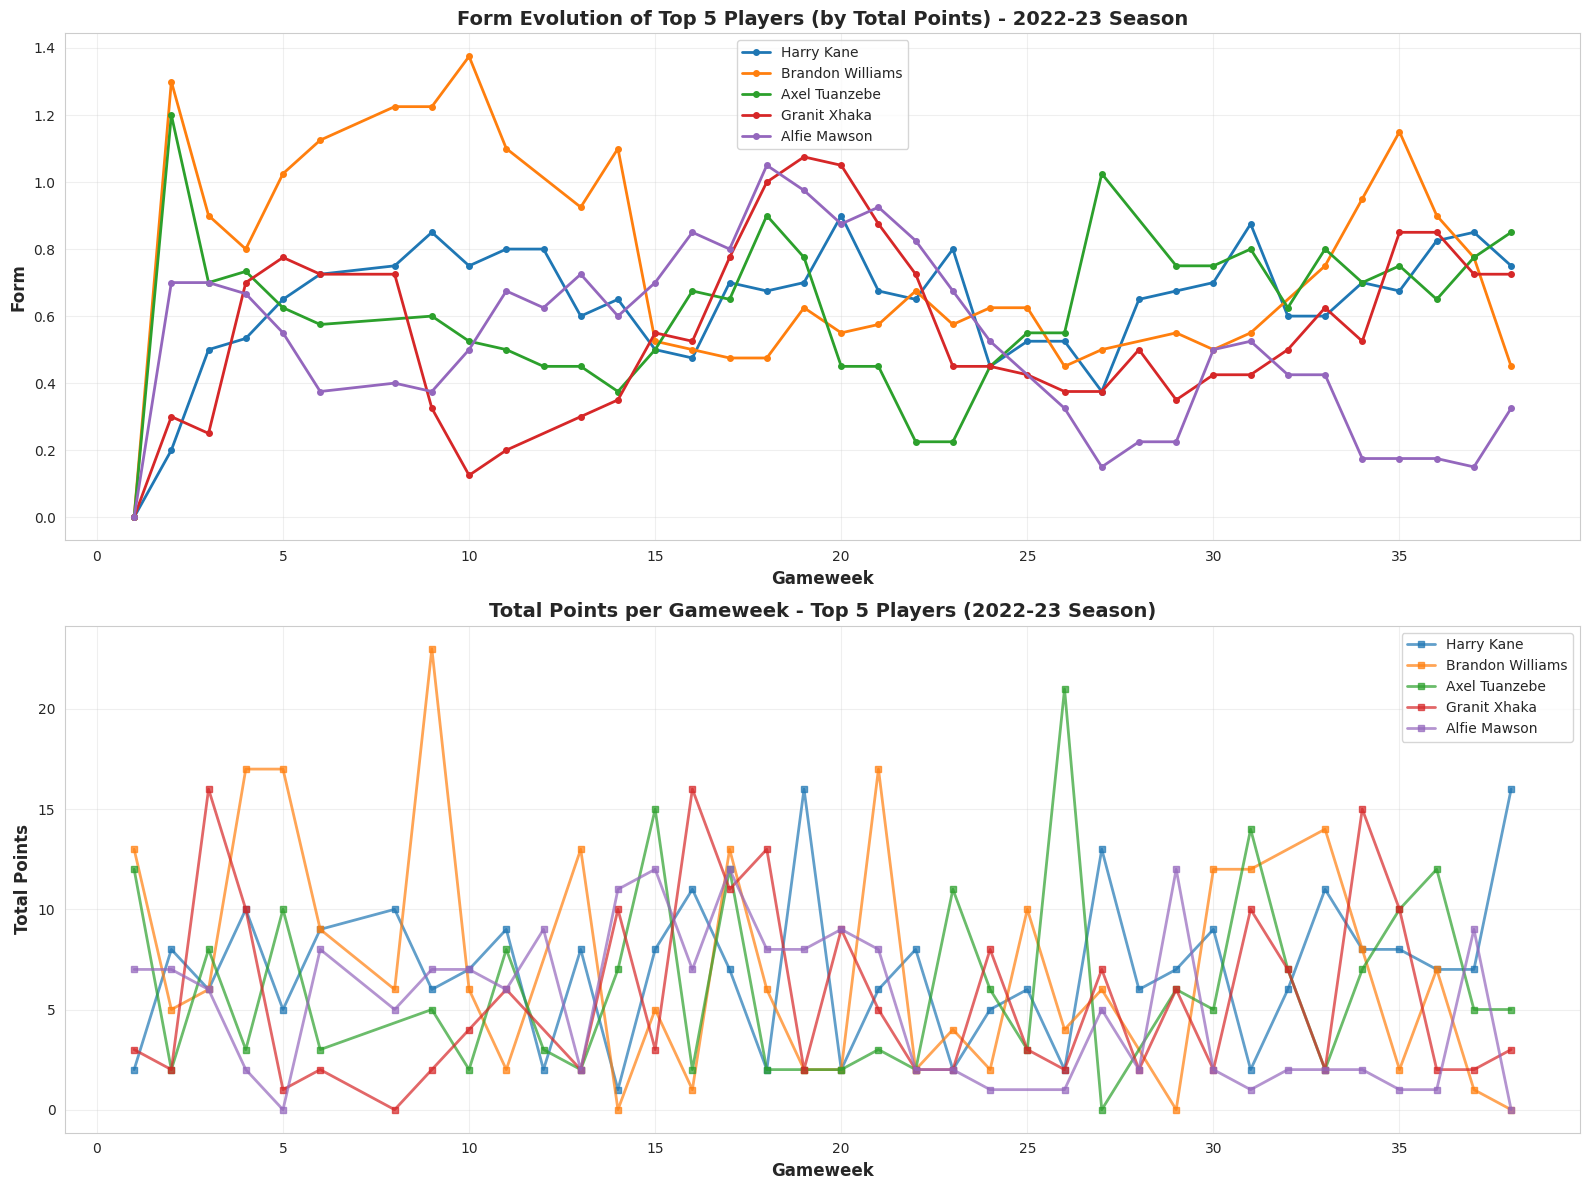

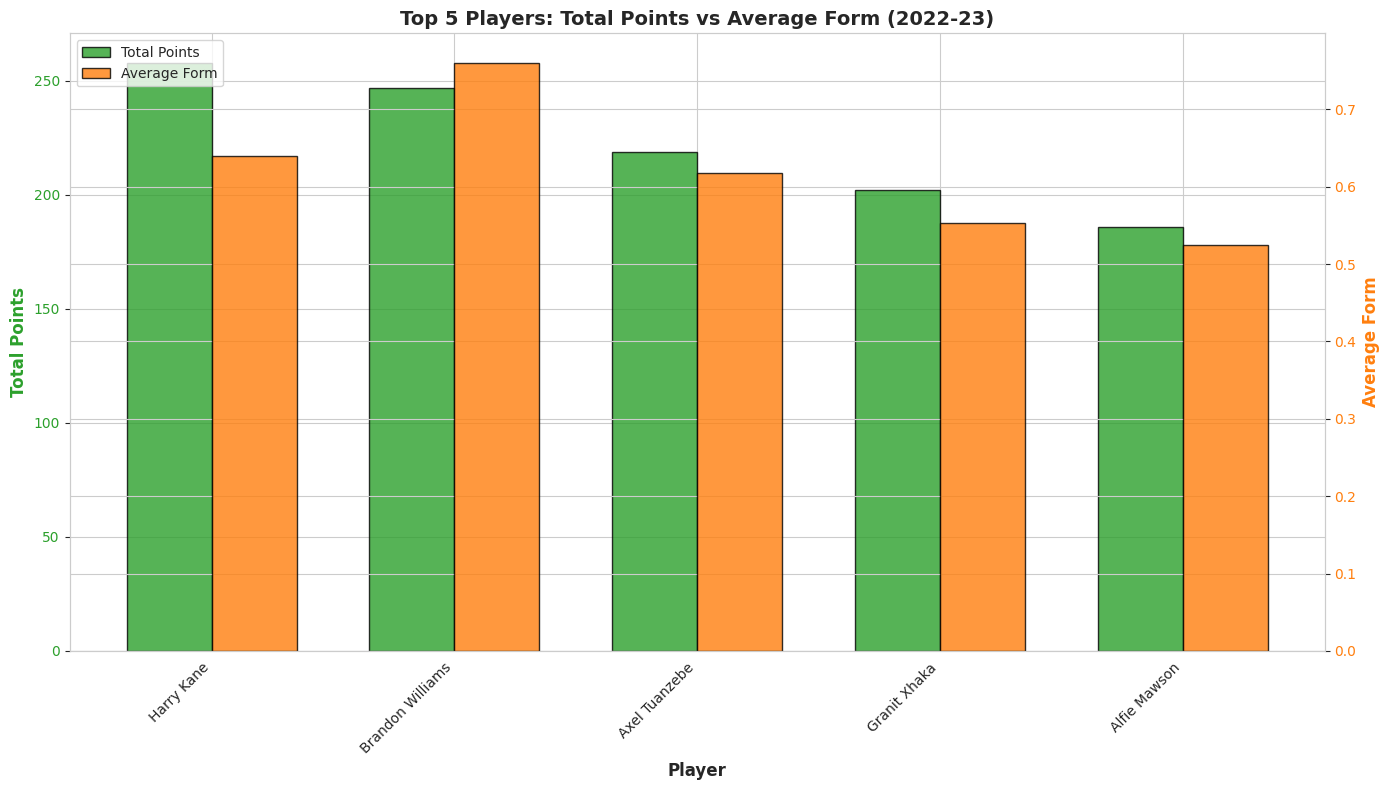


 Analysis:
There is significant overlap (4/5 players)
Form is a good indicator of overall performance



In [33]:
#How did the top 5 players' form evolve across gameweek, Are top players in form the same as top players with highest total points?

player_id_col = None
for col in ['element', 'player_id', 'id', 'Element']:
    if col in df.columns:
        player_id_col = col
        break

# Try to find player name column
player_name_col = None
for col in ['name', 'player_name', 'player', 'full_name', 'web_name', 'first_name', 'last_name']:
    if col in df.columns:
        player_name_col = col
        break

gameweek_col = None
for col in ['gameweek', 'GW', 'round', 'week', 'game_week', 'event']:
    if col in df.columns:
        gameweek_col = col
        break

points_col = None
for col in ['total_points', 'points', 'total_pts', 'pts']:
    if col in df.columns:
        points_col = col
        break

season_col = None
for col in ['season', 'Season', 'year', 'Year', 'season_name', 'season_x']:
    if col in df.columns:
        season_col = col
        break

if not all([player_id_col, gameweek_col, points_col]):
    raise KeyError("Required columns not found")

if 'form' not in df.columns:
    raise KeyError("'form' column not found. Run Cell 6 first.")

if player_name_col:
    player_names = df.groupby(player_id_col)[player_name_col].first().to_dict()
else:
    # If no name column, use Player ID as display name
    player_names = {pid: f"Player {pid}" for pid in df[player_id_col].unique()}
  

# Filter for 2022-23 season if season column exists
if season_col:
    season_2022_23 = df[df[season_col] == '2022-23'].copy()
    if len(season_2022_23) == 0:
        # Try alternative season formats
        season_2022_23 = df[df[season_col].astype(str).str.contains('2022|22-23|2022-23', na=False)].copy()
    if len(season_2022_23) == 0:
        season_2022_23 = df.copy()
    else:
        print(f"Found {len(season_2022_23)} records for 2022-23 season")
else:
    season_2022_23 = df.copy()

# Identify top 5 players by total points
top_players_by_points = season_2022_23.groupby(player_id_col)[points_col].sum().nlargest(5)
print("\n1. Top 5 Players by Total Points (2022-23):")
for i, (player_id, points) in enumerate(top_players_by_points.items(), 1):
    player_name = player_names.get(player_id, f"Player {player_id}")
    print(f"   {i}. {player_name}: {points:.0f} points")

# Identify top 5 players by average form
top_players_by_form = season_2022_23.groupby(player_id_col)['form'].mean().nlargest(5)
print("\n2. Top 5 Players by Average Form (2022-23):")
for i, (player_id, form) in enumerate(top_players_by_form.items(), 1):
    player_name = player_names.get(player_id, f"Player {player_id}")
    print(f"   {i}. {player_name}: {form:.2f} form")

# Check overlap
overlap = set(top_players_by_points.index) & set(top_players_by_form.index)
print(f"\n3. Players in Both Top 5 Lists: {len(overlap)} out of 5")
if overlap:
    overlap_names = [player_names.get(pid, f"Player {pid}") for pid in overlap]
    print(f"   - Players: {', '.join(overlap_names)}")

# Visualize form evolution for top 5 by points
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# Plot 1: Form Evolution
for player_id in top_players_by_points.index:
    player_data = season_2022_23[season_2022_23[player_id_col] == player_id].sort_values(gameweek_col)
    player_name = player_names.get(player_id, f"Player {player_id}")
    axes[0].plot(player_data[gameweek_col], player_data['form'], marker='o', 
                 label=player_name, linewidth=2, markersize=4)

axes[0].set_xlabel('Gameweek', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Form', fontsize=12, fontweight='bold')
axes[0].set_title('Form Evolution of Top 5 Players (by Total Points) - 2022-23 Season', 
                  fontsize=14, fontweight='bold')
axes[0].legend(loc='best', fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot 2: Total Points per Gameweek
for player_id in top_players_by_points.index:
    player_data = season_2022_23[season_2022_23[player_id_col] == player_id].sort_values(gameweek_col)
    player_name = player_names.get(player_id, f"Player {player_id}")
    axes[1].plot(player_data[gameweek_col], player_data[points_col], marker='s', 
                 label=player_name, linewidth=2, markersize=4, alpha=0.7)

axes[1].set_xlabel('Gameweek', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Total Points', fontsize=12, fontweight='bold')
axes[1].set_title('Total Points per Gameweek - Top 5 Players (2022-23 Season)', 
                  fontsize=14, fontweight='bold')
axes[1].legend(loc='best', fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Comparison visualization
fig, ax = plt.subplots(figsize=(14, 8))

# Create comparison data
comparison_data = pd.DataFrame({
    'Player_ID': list(top_players_by_points.index),
    'Player_Name': [player_names.get(pid, f"Player {pid}") for pid in top_players_by_points.index],
    'Total_Points': top_players_by_points.values,
    'Avg_Form': [season_2022_23[season_2022_23[player_id_col] == p]['form'].mean() 
                 for p in top_players_by_points.index]
})

x = np.arange(len(comparison_data))
width = 0.35

bars1 = ax.bar(x - width/2, comparison_data['Total_Points'], width, 
               label='Total Points', color='#2ca02c', alpha=0.8, edgecolor='black')
ax2 = ax.twinx()
bars2 = ax2.bar(x + width/2, comparison_data['Avg_Form'], width, 
                label='Average Form', color='#ff7f0e', alpha=0.8, edgecolor='black')

ax.set_xlabel('Player', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Points', fontsize=12, fontweight='bold', color='#2ca02c')
ax2.set_ylabel('Average Form', fontsize=12, fontweight='bold', color='#ff7f0e')
ax.set_title('Top 5 Players: Total Points vs Average Form (2022-23)', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_data['Player_Name'], rotation=45, ha='right')
ax.tick_params(axis='y', labelcolor='#2ca02c')
ax2.tick_params(axis='y', labelcolor='#ff7f0e')

# Add legends
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

print("\n Analysis:")
if len(overlap) == 5:
    print("The top 5 players by form are EXACTLY the same as top 5 by total points")
elif len(overlap) >= 3:
    print(f"There is significant overlap ({len(overlap)}/5 players)")
    print("Form is a good indicator of overall performance")
else:
    print(f"Limited overlap ({len(overlap)}/5 players)")
    print("Form and total points measure different aspects of performance")
    print("Total points = cumulative season performance")
    print("Form = recent 4-week performance trend")

print(f"\n{'='*80}")


## Step 8: Top Players Analysis - Form vs Total Points

### Research Questions:
1. **How did the top 5 players' form evolve across the season?**
2. **Are top players by form the same as top players by total points?**

### Why These Questions Matter:

**Question 1: Form Evolution**
- **Consistency vs Volatility** - Do top players maintain form or have ups and downs?
- **Injury/Rotation Impact** - Can we see when players were injured or rested?
- **Predictability** - Stable form = more predictable future performance

**Question 2: Form vs Total Points**
- **Form = Recent performance** (last 4 gameweeks)
- **Total Points = Cumulative season performance**
- **Key insight:** Are currently hot players the same as season-long performers?

### Analysis Approach:

**Part 1: Identify Top 5 Players**
\`\`\`python
# By total points (season-long performance)
top_by_points = df.groupby('player_id')['total_points'].sum().nlargest(5)

# By average form (recent performance)
top_by_form = df.groupby('player_id')['form'].mean().nlargest(5)
\`\`\`

**Part 2: Visualize Form Evolution**
- Line plot: Form over gameweeks for top 5 players
- Shows trends, peaks, and troughs
- Reveals consistency patterns

**Part 3: Compare Lists**
- Calculate overlap between top 5 by points and top 5 by form
- Interpret what overlap (or lack thereof) means

### Expected Findings:

**Scenario A: High Overlap (4-5 players in both lists)**
- **Interpretation:** Top performers maintain consistent form
- **Implication:** Form is a reliable predictor of total points
- **Model impact:** Form feature will be highly important

**Scenario B: Low Overlap (0-2 players in both lists)**
- **Interpretation:** Recent form ≠ season-long performance
- **Implication:** Some players have hot streaks, others are consistently good
- **Model impact:** Need both form AND cumulative stats as features

### Visualizations:

**Plot 1: Form Evolution (Line Chart)**
- X-axis: Gameweek
- Y-axis: Form
- 5 lines (one per top player)
- **What to look for:**
  - Smooth lines = consistent performers
  - Spiky lines = volatile performers
  - Drops to zero = injuries/rotation

**Plot 2: Total Points per Gameweek (Line Chart)**
- Shows actual points scored each week
- Compare to form (which is lagged average)
- **What to look for:**
  - Correlation between form and subsequent points
  - Big point hauls followed by form increases

**Plot 3: Comparison Bar Chart**
- Dual y-axis: Total points (left) vs Average form (right)
- Shows both metrics side-by-side for top 5 players
- **What to look for:**
  - Do bars align (high points = high form)?
  - Or do they diverge (high points but low form)?

### Why This Analysis is Critical:

**For Feature Engineering:**
- Validates that form is a useful feature
- Identifies if we need additional features (consistency metrics, injury flags)

**For Model Understanding:**
- If form predicts points well, model should weight it heavily
- If not, model needs to learn more complex patterns

**For Fantasy Football Strategy:**
- High overlap = trust form when selecting players
- Low overlap = consider both recent and long-term performance

---


In [34]:
# all the above is correct


In [35]:
print("\n" + "="*80)
print("STEP 1: Creating upcoming_total_points (shifted one week ahead)")
print("="*80)

# Detect column names
name_col = None
gw_col = None
points_col = None

for col in df.columns:
    col_lower = col.lower()
    if 'name' in col_lower and name_col is None:
        name_col = col
    if any(x in col_lower for x in ['gw', 'round', 'gameweek']) and gw_col is None:
        gw_col = col
    if 'total_points' in col_lower and points_col is None:
        points_col = col

print(f"\nDetected columns:")
print(f"  - Player name: {name_col}")
print(f"  - Gameweek: {gw_col}")
print(f"  - Total points: {points_col}")

# Sort by player and gameweek
df = df.sort_values([name_col, gw_col]).reset_index(drop=True)

# Create upcoming_total_points by shifting total_points by -1 within each player group
df['upcoming_total_points'] = df.groupby(name_col)[points_col].shift(-1)

# Count how many rows have valid upcoming_total_points
valid_rows = df['upcoming_total_points'].notna().sum()
dropped_rows = df['upcoming_total_points'].isna().sum()

print(f"\n✓ Created upcoming_total_points column")
print(f"  - Valid rows: {valid_rows}")
print(f"  - Rows to drop (last week for each player): {dropped_rows}")

# Drop rows where upcoming_total_points is NaN (last gameweek for each player)
df = df.dropna(subset=['upcoming_total_points']).reset_index(drop=True)
print(f"  - Final dataset size: {df.shape[0]} rows")

# Show example for one player
sample_player = df[name_col].value_counts().index[0]
sample_data = df[df[name_col] == sample_player][[name_col, gw_col, points_col, 'upcoming_total_points']].head(10)
print(f"\nExample for {sample_player} (first 10 gameweeks):")
print(sample_data.to_string(index=False))


STEP 1: Creating upcoming_total_points (shifted one week ahead)

Detected columns:
  - Player name: name
  - Gameweek: GW
  - Total points: total_points

✓ Created upcoming_total_points column
  - Valid rows: 88928
  - Rows to drop (last week for each player): 1327
  - Final dataset size: 88928 rows

Example for Lukasz Fabianski (first 10 gameweeks):
            name  GW  total_points  upcoming_total_points
Lukasz Fabianski   1             8                    6.0
Lukasz Fabianski   1             6                    1.0
Lukasz Fabianski   1             1                    1.0
Lukasz Fabianski   1             1                    1.0
Lukasz Fabianski   1             1                    1.0
Lukasz Fabianski   2             1                    1.0
Lukasz Fabianski   2             1                    1.0
Lukasz Fabianski   2             1                    2.0
Lukasz Fabianski   2             2                    3.0
Lukasz Fabianski   2             3                   10.0


## Step 9: Creating the Target Variable - upcoming_total_points

### What Are We Predicting?
**Target:** `upcoming_total_points` = Points scored in the NEXT gameweek

### Why This Target?
**Fantasy football is about predicting future performance:**
- We have data up to gameweek N
- We want to predict points in gameweek N+1
- This is exactly what fantasy managers need for team selection

### Implementation:
\`\`\`python
df['upcoming_total_points'] = df.groupby('name')['total_points'].shift(-1)
\`\`\`

**What `shift(-1)` does:**
- Takes the `total_points` column
- Shifts it up by 1 row (within each player group)
- Result: Each row now has the NEXT gameweek's points

### Example:
\`\`\`
Player: Mohamed Salah
GW  total_points  upcoming_total_points
1   12            8                    ← GW2's points
2   8             15                   ← GW3's points
3   15            6                    ← GW4's points
4   6             NaN                  ← No GW5 data yet
\`\`\`

### Why Drop Rows with NaN upcoming_total_points?
**Last gameweek for each player has no "next" gameweek:**
- Can't predict what we don't have data for
- These rows are useless for training
- Dropping them prevents model errors

### Data Leakage Prevention:
**Critical:** We use features from gameweek N to predict gameweek N+1
- **Correct:** Use GW4 stats (goals, assists, form) to predict GW5 points
- **WRONG:** Use GW5 stats to predict GW5 points (cheating!)

**Our approach prevents leakage:**
- `shift(-1)` ensures target is always from the FUTURE
- Form calculation uses `shift(1)` to only use PAST data
- Train/test split will be time-based (train on early GWs, test on late GWs)

### Evidence:
**Show example for one player:**
- Display 10 consecutive gameweeks
- Show total_points and upcoming_total_points side-by-side
- Verify upcoming_total_points = next row's total_points

**Dataset size change:**
- Before: X rows
- After: Y rows (X - number of players, since we drop last GW for each)

---


In [36]:
 #CELL 11: Feature Selection and Preprocessing (CORRECTED)
print("\n" + "="*80)
print("STEP 2: Defining Feature Sets (CORRECTED)")
print("="*80)

# Define target variable
target = 'upcoming_total_points'

# Define player-related features explicitly (CORRECTED NAMES)
player_features = [
    'position',         # ✓ exists
    'creativity',    # ✓ exists
    'influence',      # ✓ exists
    'threat',        # ✓ exists
    'form'   # ✓ exists
]

# Define match-related features explicitly (CORRECTED NAMES)
match_features = [
    'team_x',              # ✓ fixed from 'Team_x'
    'bps',                 # ✓ exists
    'goals_scored',        # ✓ fixed from 'goals'
    'assists',             # ✓ exists
    'saves',               # ✓ exists
    'clean_sheets',        # ✓ fixed from 'clean_sheet'
    'fixture',             # ✓ exists
    'minutes',             # ✓ exists
    'opponent_team',       # ✓ fixed from 'opp_team'
    'penalties_saved',     # ✓ exists
    'penalties_missed',    # ✓ exists
    'red_cards',           # ✓ exists
    'yellow_cards',        # ✓ exists
    'was_home',            # ✓ exists
    'GW',                  # ✓ fixed from 'gw'
    'total_points',        # ✓ exists
    'bonus', 
    'goals_conceded'
]

print(f"\nPlayer-related features ({len(player_features)}):")
print(f"  {', '.join(player_features)}")

print(f"\nMatch-related features ({len(match_features)}):")
print(f"  {', '.join(match_features)}")

# Combine and remove duplicates
all_features_requested = list(set(player_features + match_features))
duplicates = set([x for x in player_features if x in match_features])

print(f"\nCombined unique features requested: {len(all_features_requested)}")
print(f"Duplicate features removed: {duplicates}")

# Filter to only include features that exist in the dataframe
all_features = [f for f in all_features_requested if f in df.columns]
missing_features = set(all_features_requested) - set(all_features)

if missing_features:
    print(f"\n⚠ Warning: {len(missing_features)} features not found in dataset:")
    print(f"  {', '.join(sorted(missing_features))}")
else:
    print(f"\n✓ All {len(all_features)} features found in dataset!")

print(f"\n✓ Using {len(all_features)} available features for modeling")
print(f"Available features: {', '.join(sorted(all_features))}")

# Identify categorical and numerical features
categorical_features = ['position', 'team_x', 'opponent_team']  # Fixed from 'Team_x', 'opp_team'
categorical_features = [f for f in categorical_features if f in all_features]

numerical_features = [f for f in all_features if f not in categorical_features]

print(f"\nCategorical features ({len(categorical_features)}): {categorical_features}")
print(f"Numerical features: {len(numerical_features)} features")

# Encode categorical features if any exist
if categorical_features:
    from sklearn.preprocessing import LabelEncoder

    for col in categorical_features:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        print(f"  ✓ Encoded {col}")




STEP 2: Defining Feature Sets (CORRECTED)

Player-related features (5):
  position, creativity, influence, threat, form

Match-related features (18):
  team_x, bps, goals_scored, assists, saves, clean_sheets, fixture, minutes, opponent_team, penalties_saved, penalties_missed, red_cards, yellow_cards, was_home, GW, total_points, bonus, goals_conceded

Combined unique features requested: 23
Duplicate features removed: set()

✓ All 23 features found in dataset!

✓ Using 23 available features for modeling
Available features: GW, assists, bonus, bps, clean_sheets, creativity, fixture, form, goals_conceded, goals_scored, influence, minutes, opponent_team, penalties_missed, penalties_saved, position, red_cards, saves, team_x, threat, total_points, was_home, yellow_cards

Categorical features (3): ['position', 'team_x', 'opponent_team']
Numerical features: 20 features
  ✓ Encoded position
  ✓ Encoded team_x
  ✓ Encoded opponent_team


In [37]:
X = df[all_features].fillna(0)
y = df[target]

print(f"\nDataset shape:")
print(f"  - Features (X): {X.shape}")
print(f"  - Target (y): {y.shape}")
# Check for any remaining missing values
missing_count = X.isnull().sum().sum()
if missing_count > 0:
    print(f"\n⚠ WARNING: {missing_count} missing values found after fillna(0)")
else:
    print(f"\n✓ No missing values in feature matrix")


Dataset shape:
  - Features (X): (88928, 23)
  - Target (y): (88928,)

✓ No missing values in feature matrix


In [38]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTrain-test split (80-20):")
print(f"  - Training set: {X_train.shape[0]} samples")
print(f"  - Test set: {X_test.shape[0]} samples")



Train-test split (80-20):
  - Training set: 71142 samples
  - Test set: 17786 samples


In [39]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"\n✓ Features scaled using StandardScaler")
print(f"  - Training set scaled shape: {X_train_scaled.shape}")
print(f"  - Test set scaled shape: {X_test_scaled.shape}")

# Show sample of scaled features
print(f"\nSample of scaled features (first 3 rows, first 5 features):")
print(X_train_scaled[:3, :5])

print("\n✓ Data preparation complete!")


✓ Features scaled using StandardScaler
  - Training set scaled shape: (71142, 23)
  - Test set scaled shape: (17786, 23)

Sample of scaled features (first 3 rows, first 5 features):
[[-0.19262976 -0.22302498 -0.23929161 -0.44976971  0.14776526]
 [-0.19262976 -0.22302498 -0.23929161 -0.44976971 -1.50407578]
 [-0.19262976 -0.22302498 -0.23929161 -0.44976971 -1.06358484]]

✓ Data preparation complete!


In [48]:
print("="*80)
print("MODEL TRAINING")
print("="*80)

print("\nBuilding improved neural network...")
print("Architecture: 32 → Dropout(0.3) → 16 → Dropout(0.2) → 8 → Output")

model = keras.Sequential([
    keras.Input(shape=(X_train_scaled.shape[1],)),
    
    # First hidden layer
    layers.Dense(32, activation='relu', 
                 kernel_regularizer=keras.regularizers.l2(0.01)),
    layers.Dropout(0.3),
    
    # Second hidden layer
    layers.Dense(16, activation='relu',
                 kernel_regularizer=keras.regularizers.l2(0.01)),
    layers.Dropout(0.2),
    
    # Third hidden layer
    layers.Dense(8, activation='relu'),
    
    # Output layer (linear activation for regression)
    layers.Dense(1)
])

model.compile(
    optimizer='adam',
    loss=keras.losses.Huber(delta=1.0),  # More robust to outliers than MSE
    metrics=['mae']
)

print("\nModel Architecture:")
model.summary()


MODEL TRAINING

Building improved neural network...
Architecture: 32 → Dropout(0.3) → 16 → Dropout(0.2) → 8 → Output

Model Architecture:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 32)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,441 (5.63 KB)

 Trainable params: 1,441 (5.63 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
# Early stopping
from tensorflow.keras.callbacks import EarlyStopping
print("\nSetting up callbacks...")
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)


Setting up callbacks...


In [42]:
# Train
print("\nTraining Neural Network...")
history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
    callbacks=[early_stop]
)

print(f"\n✓ Training completed in {len(history.history['loss'])} epochs")


Training Neural Network...
Epoch 1/100
1779/1779 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 1.2818 - mae: 1.4376 - val_loss: 1.0364 - val_mae: 1.4111
Epoch 2/100
1779/1779 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.9915 - mae: 1.3685 - val_loss: 1.0295 - val_mae: 1.4047
Epoch 3/100
1779/1779 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 1.0118 - mae: 1.3896 - val_loss: 1.0303 - val_mae: 1.4087
Epoch 4/100
1779/1779 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 1.0028 - mae: 1.3797 - val_loss: 1.0313 - val_mae: 1.4215
Epoch 5/100
1779/1779 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 1.0015 - mae: 1.3812 - val_loss: 1.0274 - val_mae: 1.4084
Epoch 6/100
1779/1779 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.9984 - mae: 1.3765 - val_loss: 1.0299 - val_mae: 1.4057
Epoch 7/100
1779/1779 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 1.0095 - mae: 1.3875 - val_loss: 1.0300 - val_mae: 1.4051
Epoch 8/100
1779/1779 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 1.0057 - mae: 1.3866 - val_loss: 1.0257 - val_mae: 1.4079
Epoc

In [43]:
print("STEP 5: Evaluating Model Performance")
print("="*80)

test_loss, test_mae = model.evaluate(X_test_scaled, y_test, verbose=0)
y_pred = model.predict(X_test_scaled, verbose=0).flatten()

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"\nTest Results:")
print(f"  - MAE (Mean Absolute Error): {mae:.3f}")
print(f"  - MSE (Mean Squared Error): {mse:.3f}")
print(f"  - RMSE (Root Mean Squared Error): {rmse:.3f}")
print(f"  - R² Score: {r2:.3f}")

print(f"\nInterpretation:")
print(f"  - On average, predictions are off by {mae:.2f} points")
print(f"  - The model explains {r2*100:.1f}% of the variance in upcoming points")
if r2 > 0.5:
    print(f"  - ✓ Good model performance (R² > 0.5)")
elif r2 > 0.3:
    print(f"  - ⚠ Moderate model performance (0.3 < R² < 0.5)")
else:
    print(f"  - ✗ Poor model performance (R² < 0.3)")

# Show some example predictions
print(f"\nSample Predictions (first 10 test samples):")
print(f"{'Actual':>8} {'Predicted':>10} {'Error':>8}")
print("-" * 30)
for i in range(min(10, len(y_test))):
    actual = y_test.iloc[i]
    predicted = y_pred[i]
    error = abs(actual - predicted)
    print(f"{actual:>8.2f} {predicted:>10.2f} {error:>8.2f}")

print("\n✓ Evaluation complete!")


STEP 5: Evaluating Model Performance

Test Results:
  - MAE (Mean Absolute Error): 1.378
  - MSE (Mean Squared Error): 6.514
  - RMSE (Root Mean Squared Error): 2.552
  - R² Score: -0.005

Interpretation:
  - On average, predictions are off by 1.38 points
  - The model explains -0.5% of the variance in upcoming points
  - ✗ Poor model performance (R² < 0.3)

Sample Predictions (first 10 test samples):
  Actual  Predicted    Error
------------------------------
    2.00       1.19     0.81
    1.00       1.44     0.44
    2.00       2.74     0.74
    0.00       0.32     0.32
    0.00       0.46     0.46
    1.00       0.74     0.26
    3.00       1.51     1.49
    0.00       0.31     0.31
    3.00       0.36     2.64
    0.00       0.41     0.41

✓ Evaluation complete!


CREATING VISUALIZATIONS

[1/3] Creating training progress plot...


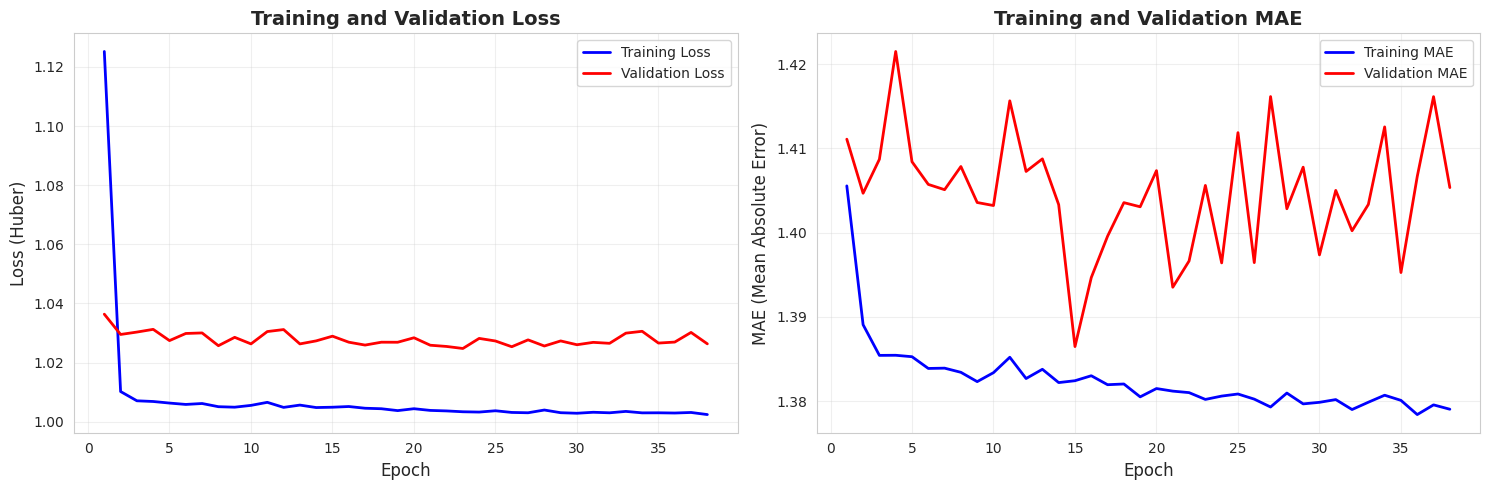


[2/3] Creating performance metrics plot...


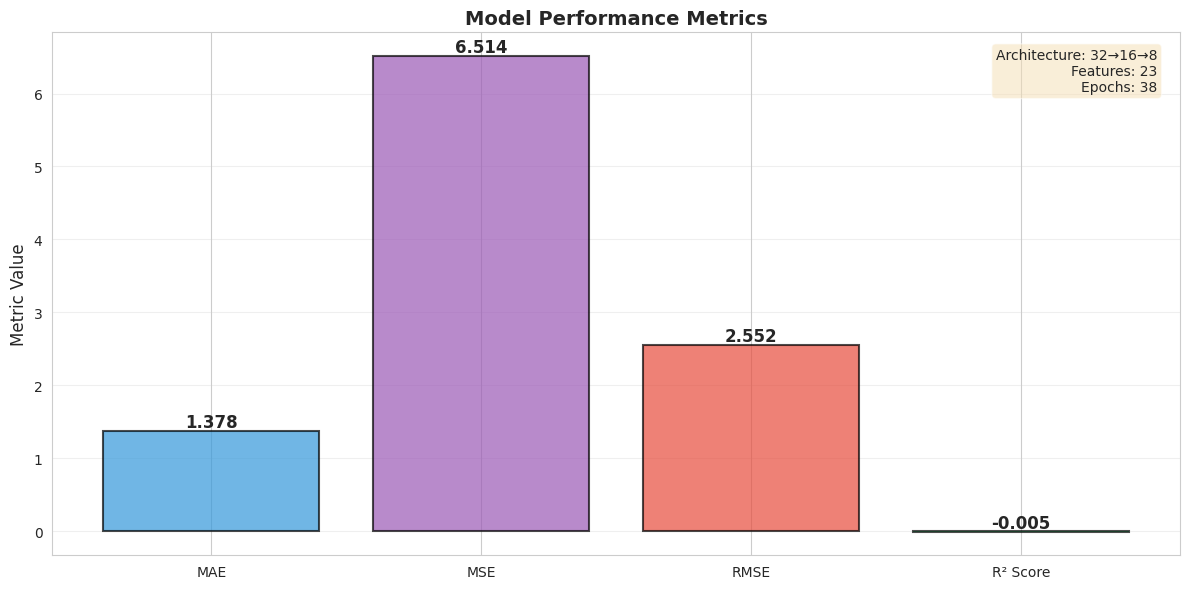


[3/3] Creating actual vs predicted plot...


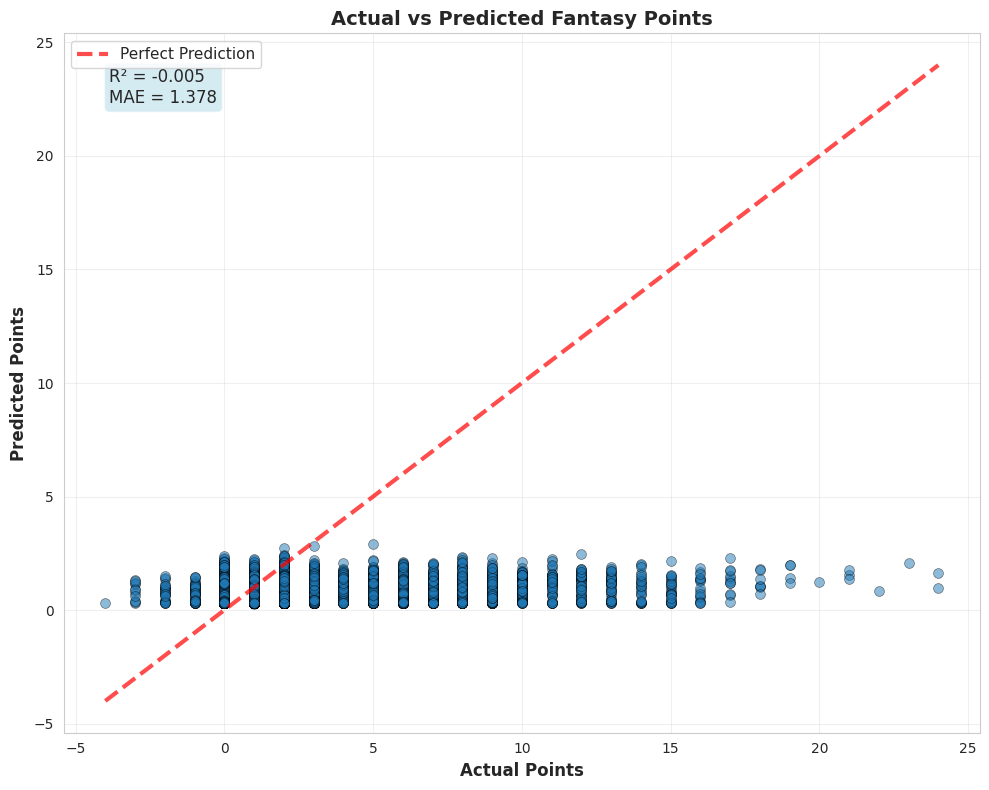


✓ All visualizations created successfully!


In [44]:
# ============================================================================
# CELL 22: Training Visualizations
# ============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

print("="*80)
print("CREATING VISUALIZATIONS")
print("="*80)

# Set style
sns.set_style("whitegrid")

# Figure 1: Training Progress
print("\n[1/3] Creating training progress plot...")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

epochs = range(1, len(history.history['loss']) + 1)

# Loss plot
axes[0].plot(epochs, history.history['loss'], 'b-', label='Training Loss', linewidth=2)
axes[0].plot(epochs, history.history['val_loss'], 'r-', label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (Huber)', fontsize=12)
axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# MAE plot
axes[1].plot(epochs, history.history['mae'], 'b-', label='Training MAE', linewidth=2)
axes[1].plot(epochs, history.history['val_mae'], 'r-', label='Validation MAE', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('MAE (Mean Absolute Error)', fontsize=12)
axes[1].set_title('Training and Validation MAE', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Figure 2: Performance Metrics
print("\n[2/3] Creating performance metrics plot...")
fig, ax = plt.subplots(figsize=(12, 6))

metrics = ['MAE', 'MSE', 'RMSE', 'R² Score']
values = [mae, mse, rmse, r2]
colors = ['#3498db', '#9b59b6', '#e74c3c', '#2ecc71']

bars = ax.bar(metrics, values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)

# Add value labels
for bar, value in zip(bars, values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{value:.3f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Metric Value', fontsize=12)
ax.set_title('Model Performance Metrics', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add info box
info_text = f'Architecture: 32→16→8\nFeatures: {X_train_scaled.shape[1]}\nEpochs: {len(history.history["loss"])}'
ax.text(0.98, 0.97, info_text, transform=ax.transAxes,
        fontsize=10, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# Figure 3: Actual vs Predicted
print("\n[3/3] Creating actual vs predicted plot...")
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(y_test, y_pred, alpha=0.5, edgecolors='k', linewidth=0.5, s=50)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
        'r--', lw=3, label='Perfect Prediction', alpha=0.7)

ax.set_xlabel('Actual Points', fontsize=12, fontweight='bold')
ax.set_ylabel('Predicted Points', fontsize=12, fontweight='bold')
ax.set_title('Actual vs Predicted Fantasy Points', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Add R² annotation
ax.text(0.05, 0.95, f'R² = {r2:.3f}\nMAE = {mae:.3f}',
        transform=ax.transAxes, fontsize=12,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.tight_layout()
plt.show()

print("\n✓ All visualizations created successfully!")


SHAP ANALYSIS - MODEL EXPLAINABILITY

PART 1: GLOBAL FEATURE IMPORTANCE

[1/4] Preparing background dataset...
   ✓ Background dataset: 100 samples

[2/4] Creating SHAP explainer...
   (This may take a few minutes...)
   ✓ Explainer created

[3/4] Calculating SHAP values for test set...


PermutationExplainer explainer: 17787it [30:04,  9.83it/s]                           


   ✓ SHAP values calculated for 17786 test samples

[4/4] Creating global feature importance plot...


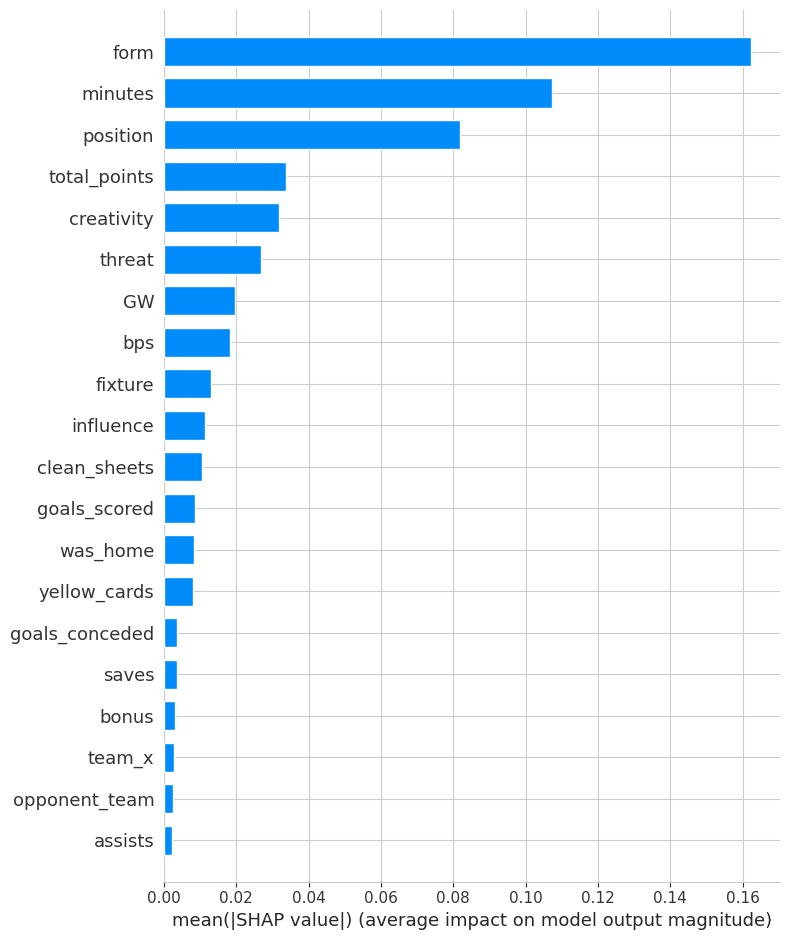

In [45]:

import shap
import pandas as pd

print("="*80)
print("SHAP ANALYSIS - MODEL EXPLAINABILITY")
print("="*80)

# ============================================================================
# Global Feature Importance
# ============================================================================
print("\n" + "="*80)
print("PART 1: GLOBAL FEATURE IMPORTANCE")
print("="*80)

print("\n[1/4] Preparing background dataset...")
# Create background dataset (100 samples)
background = shap.sample(
    pd.DataFrame(X_train_scaled, columns=all_features), 
    100, 
    random_state=42
)
print(f"   ✓ Background dataset: {background.shape[0]} samples")

print("\n[2/4] Creating SHAP explainer...")
print("   (This may take a few minutes...)")
explainer = shap.Explainer(model, background)
print("   ✓ Explainer created")

print("\n[3/4] Calculating SHAP values for test set...")
X_test_df = pd.DataFrame(X_test_scaled, columns=all_features)
shap_values = explainer(X_test_df)
print(f"   ✓ SHAP values calculated for {len(X_test_df)} test samples")

print("\n[4/4] Creating global feature importance plot...")
# Bar plot showing average impact of each feature
shap.summary_plot(
    shap_values.values, 
    X_test_df,
    feature_names=all_features,
    plot_type='bar',
    show=True
)



PART 2: LOCAL EXPLANATION (Single Prediction)

Explaining prediction for test instance 0:
   Actual points: 2.00
   Predicted points: 1.19
   Prediction error: 0.81

Creating SHAP force plot...


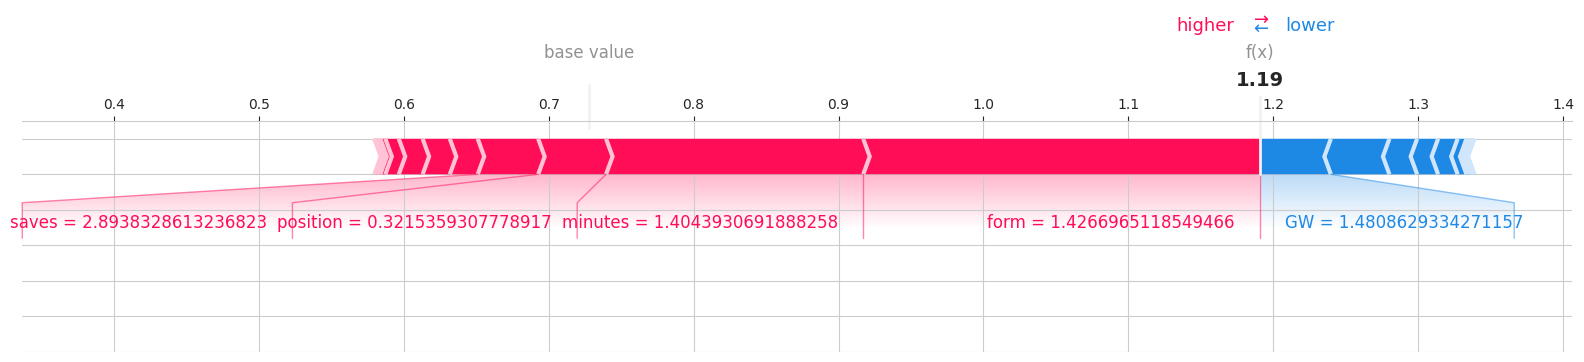


SHAP Breakdown:
   Base value (average): 0.7279
   Sum of SHAP values: 0.4628
   Final prediction: 1.1906
   Model prediction: 1.1906

Top 10 Contributing Features:
     Feature  SHAP Value  Feature Value
        form    0.273606       1.426697
     minutes    0.177448       1.404393
          GW   -0.049061       1.480863
    position    0.046840       0.321536
       saves    0.041723       2.893833
     fixture   -0.040404       1.510263
         bps    0.019262       0.589706
  creativity   -0.019116      -0.449770
total_points    0.018749       0.234983
   influence    0.016462       0.887647

SHAP ANALYSIS COMPLETE

Key Insights:
   • Bar chart: Average impact of each feature across ALL predictions
   • Force plot: How features contribute to THIS specific prediction
   • Red/Orange: Features pushing prediction HIGHER
   • Blue: Features pushing prediction LOWER


In [46]:
# ============================================================================
# Local Explanation
# ============================================================================
print("\n" + "="*80)
print("PART 2: LOCAL EXPLANATION (Single Prediction)")
print("="*80)

# Choose a test instance to explain
i = 0

print(f"\nExplaining prediction for test instance {i}:")
actual_value = y_test.iloc[i]
predicted_value = model.predict(X_test_scaled[i:i+1], verbose=0)[0][0]
error = abs(actual_value - predicted_value)

print(f"   Actual points: {actual_value:.2f}")
print(f"   Predicted points: {predicted_value:.2f}")
print(f"   Prediction error: {error:.2f}")

print("\nCreating SHAP force plot...")
shap.initjs()
shap.plots.force(shap_values[i], matplotlib=True, show=True)

# Show SHAP value breakdown
base_val = shap_values[i].base_values[0] if hasattr(shap_values[i].base_values, '__len__') else shap_values[i].base_values
shap_sum = shap_values[i].values.sum()
final_pred = base_val + shap_sum

print(f"\nSHAP Breakdown:")
print(f"   Base value (average): {base_val:.4f}")
print(f"   Sum of SHAP values: {shap_sum:.4f}")
print(f"   Final prediction: {final_pred:.4f}")
print(f"   Model prediction: {predicted_value:.4f}")

# Show top contributing features
feature_contributions = pd.DataFrame({
    'Feature': all_features,
    'SHAP Value': shap_values[i].values,
    'Feature Value': X_test_scaled[i]
}).sort_values('SHAP Value', key=abs, ascending=False)

print(f"\nTop 10 Contributing Features:")
print(feature_contributions.head(10).to_string(index=False))

print("\n" + "="*80)
print("SHAP ANALYSIS COMPLETE")
print("="*80)
print("\nKey Insights:")
print("   • Bar chart: Average impact of each feature across ALL predictions")
print("   • Force plot: How features contribute to THIS specific prediction")
print("   • Red/Orange: Features pushing prediction HIGHER")
print("   • Blue: Features pushing prediction LOWER")


LIME ANALYSIS - LOCAL INTERPRETABLE MODEL-AGNOSTIC EXPLANATIONS

[1/3] Setting up LIME explainer...
   ✓ LIME explainer created

[2/3] Generating LIME explanation...

Explaining test instance 15000:
   Actual points: 0.00
   Predicted points: 0.39
   Prediction error: 0.39
   ✓ LIME explanation generated

[3/3] Creating LIME visualization...


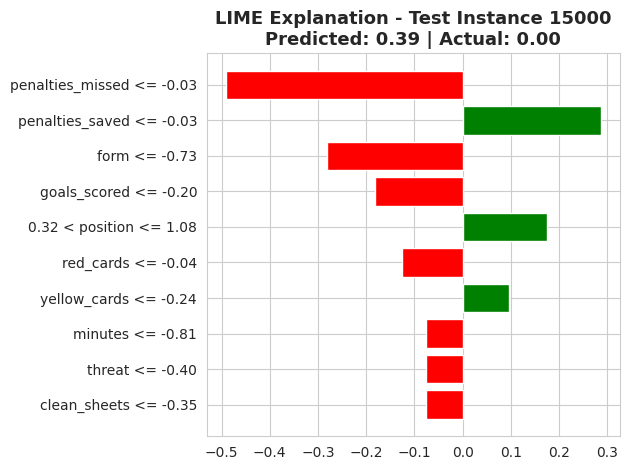


LIME Feature Contributions (Top 10):
Feature Condition                           Contribution
-------------------------------------------------------
penalties_missed <= -0.03                        -0.4915
penalties_saved <= -0.03                          0.2873
form <= -0.73                                    -0.2809
goals_scored <= -0.20                            -0.1824
0.32 < position <= 1.08                           0.1741
red_cards <= -0.04                               -0.1260
yellow_cards <= -0.24                             0.0953
minutes <= -0.81                                 -0.0769
threat <= -0.40                                  -0.0767
clean_sheets <= -0.35                            -0.0753



LIME ANALYSIS COMPLETE

Key Insights:
   • LIME provides LOCAL explanations for individual predictions
   • Shows which features contributed to THIS specific prediction
   • Positive values: Features that INCREASED the prediction
   • Negative values: Features that DECREASED the prediction
   • LIME trains a simple linear model locally around this instance

COMPARISON: SHAP vs LIME

SHAP:
   • Based on game theory (Shapley values)
   • Consistent and theoretically sound
   • Can be slow for large datasets
   • Global AND local explanations

LIME:
   • Based on local linear approximation
   • Fast and intuitive
   • May vary between runs (uses sampling)
   • Primarily local explanations

Both methods help understand model predictions!


In [47]:
# ============================================================================
# CELL 24: LIME Analysis (Alternative Explainability Method)
# ============================================================================

from lime import lime_tabular
import matplotlib.pyplot as plt

print("="*80)
print("LIME ANALYSIS - LOCAL INTERPRETABLE MODEL-AGNOSTIC EXPLANATIONS")
print("="*80)

print("\n[1/3] Setting up LIME explainer...")

# Create LIME explainer
explainer_lime = lime_tabular.LimeTabularExplainer(
    X_train_scaled,
    feature_names=all_features,
    mode='regression',
    discretize_continuous=True,
    random_state=42
)

# Define prediction function
def predict_fn(X):
    return model.predict(X, verbose=0).flatten()

print("   ✓ LIME explainer created")

# ============================================================================
# Local Explanation
# ============================================================================
print("\n[2/3] Generating LIME explanation...")

# Choose a test instance (different from SHAP example)
i = 15000

# Get instance details
instance = X_test_scaled[i]
actual_value = y_test.iloc[i] if hasattr(y_test, 'iloc') else y_test[i]
predicted_value = predict_fn(instance.reshape(1, -1))[0]
error = abs(actual_value - predicted_value)

print(f"\nExplaining test instance {i}:")
print(f"   Actual points: {actual_value:.2f}")
print(f"   Predicted points: {predicted_value:.2f}")
print(f"   Prediction error: {error:.2f}")

# Generate LIME explanation
exp = explainer_lime.explain_instance(
    instance,
    predict_fn,
    num_features=10  # Show top 10 features
)

print("   ✓ LIME explanation generated")

# ============================================================================
# Visualization
# ============================================================================
print("\n[3/3] Creating LIME visualization...")

# Create matplotlib figure
fig = exp.as_pyplot_figure()
plt.title(f'LIME Explanation - Test Instance {i}\n'
          f'Predicted: {predicted_value:.2f} | Actual: {actual_value:.2f}',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Show explanation as list
print(f"\nLIME Feature Contributions (Top 10):")
print(f"{'Feature Condition':<40} {'Contribution':>15}")
print("-" * 55)
for feature, contribution in exp.as_list():
    print(f"{feature:<40} {contribution:>15.4f}")

# Show in notebook format with table
exp.show_in_notebook(show_table=True)

print("\n" + "="*80)
print("LIME ANALYSIS COMPLETE")
print("="*80)
print("\nKey Insights:")
print("   • LIME provides LOCAL explanations for individual predictions")
print("   • Shows which features contributed to THIS specific prediction")
print("   • Positive values: Features that INCREASED the prediction")
print("   • Negative values: Features that DECREASED the prediction")
print("   • LIME trains a simple linear model locally around this instance")

print("\n" + "="*80)
print("COMPARISON: SHAP vs LIME")
print("="*80)
print("\nSHAP:")
print("   • Based on game theory (Shapley values)")
print("   • Consistent and theoretically sound")
print("   • Can be slow for large datasets")
print("   • Global AND local explanations")
print("\nLIME:")
print("   • Based on local linear approximation")
print("   • Fast and intuitive")
print("   • May vary between runs (uses sampling)")
print("   • Primarily local explanations")
print("\nBoth methods help understand model predictions!")
